In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler ,OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [35]:
df=pd.read_csv("Heart_Disease.csv")

In [36]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [37]:
x = df.drop(columns=["TenYearCHD"])   # Input features
y = df["TenYearCHD"]                  # Target variable

In [38]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [39]:
x.corr(numeric_only=True)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
male,1.000000,-0.028979,0.017352,0.197596,0.317930,-0.052506,-0.004546,0.005313,0.015708,-0.070322,-0.035989,0.057933,0.081672,-0.116620,0.006083
age,-0.028979,1.000000,-0.165883,-0.213748,-0.192791,0.122995,0.057655,0.307194,0.101258,0.262131,0.394302,0.206104,0.135800,-0.012823,0.122256
education,0.017352,-0.165883,1.000000,0.018532,0.008085,-0.010815,-0.035112,-0.081970,-0.038680,-0.023115,-0.129631,-0.062316,-0.137504,-0.054206,-0.035721
currentSmoker,0.197596,-0.213748,0.018532,1.000000,0.769690,-0.048938,-0.032988,-0.103260,-0.044295,-0.046562,-0.130230,-0.107746,-0.167650,0.062356,-0.056826
cigsPerDay,0.317930,-0.192791,0.008085,0.769690,1.000000,-0.046134,-0.032707,-0.066146,-0.037067,-0.026320,-0.088780,-0.056632,-0.092856,0.075157,-0.058960
BPMeds,-0.052506,0.122995,-0.010815,-0.048938,-0.046134,1.000000,0.117365,0.261187,0.052047,0.080558,0.254219,0.194227,0.100668,0.015233,0.051176
prevalentStroke,-0.004546,0.057655,-0.035112,-0.032988,-0.032707,0.117365,1.000000,0.074830,0.006949,0.000067,0.057009,0.045190,0.025891,-0.017676,0.018431
prevalentHyp,0.005313,0.307194,-0.081970,-0.103260,-0.066146,0.261187,0.074830,1.000000,0.077808,0.163993,0.696755,0.615751,0.301318,0.147261,0.086834
diabetes,0.015708,0.101258,-0.038680,-0.044295,-0.037067,0.052047,0.006949,0.077808,1.000000,0.040278,0.111283,0.050329,0.087036,0.048994,0.617627
totChol,-0.070322,0.262131,-0.023115,-0.046562,-0.026320,0.080558,0.000067,0.163993,0.040278,1.000000,0.208908,0.165182,0.115767,0.091125,0.046408


In [40]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

<Axes: >

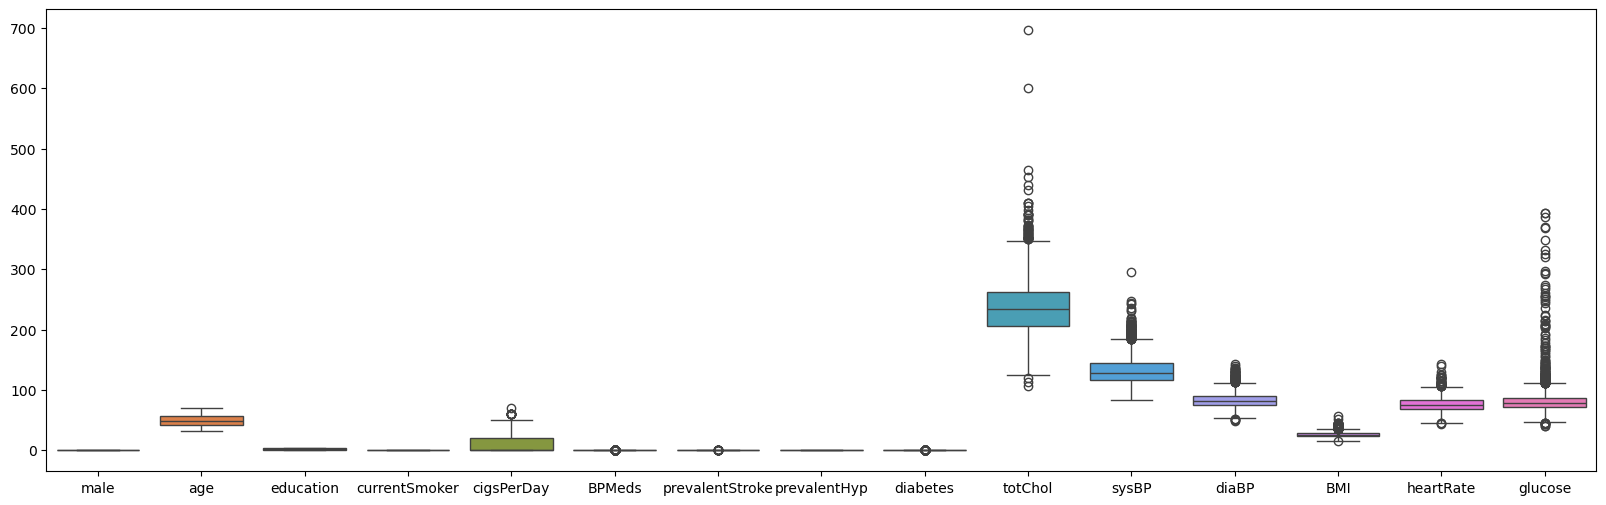

In [41]:
plt.figure(figsize=(20,6))
sns.boxplot(data=x[num_cols])

In [42]:
xtrain[obj_cols].nunique()

Series([], dtype: float64)

In [43]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
scaling=MinMaxScaler()
model=LogisticRegression(class_weight='balanced', max_iter=1000)
#model=LogisticRegression(penalty='l2',solver='liblinear')
#model=LogisticRegression(penalty='None')

In [44]:
#xtrain update

xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
#xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols])
encoded_values=encoder.fit_transform(xtrain[obj_cols])
encoded_columns=encoder.get_feature_names_out()
xtrain[encoded_columns]=encoded_values
xtrain.drop(columns=obj_cols,inplace=True)


In [45]:
xtrain

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
3252,1.0,0.210526,1.000000,1.0,0.500000,0.0,0.0,0.0,0.0,0.166384,0.224586,0.358696,0.198740,0.214286,0.132768
3946,0.0,0.657895,0.333333,0.0,0.000000,0.0,0.0,1.0,0.0,0.242784,0.326241,0.483696,0.406447,0.306122,0.152542
1261,0.0,0.394737,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.208829,0.186761,0.250000,0.277266,0.387755,0.093220
2536,1.0,0.236842,0.333333,1.0,0.500000,0.0,0.0,0.0,0.0,0.205433,0.139480,0.375000,0.245516,0.224490,0.084746
4089,0.0,0.842105,0.000000,0.0,0.000000,0.0,0.0,1.0,0.0,0.212224,0.312057,0.391304,0.119971,0.234694,0.158192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3444,0.0,0.105263,0.000000,1.0,0.083333,0.0,0.0,1.0,0.0,0.195246,0.300236,0.500000,0.272661,0.316327,0.087571
466,0.0,0.657895,0.666667,1.0,0.250000,0.0,0.0,0.0,0.0,0.242784,0.196217,0.282609,0.134270,0.357143,0.090395
3092,0.0,0.736842,0.333333,0.0,0.000000,0.0,0.0,1.0,0.0,0.324278,0.234043,0.445652,0.231459,0.387755,0.115819
3772,1.0,0.184211,0.333333,1.0,0.166667,0.0,0.0,0.0,0.0,0.183362,0.087470,0.179348,0.217159,0.234694,0.062147


In [46]:

xtest[num_cols]=scaling.transform(xtest[num_cols])
# xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols])
encoded_values=encoder.transform(xtest[obj_cols])
encoded_columns=encoder.get_feature_names_out()
xtest[encoded_columns]=encoded_values
xtest.drop(columns=obj_cols,inplace=True)

#ValueError: Input X contains NaN.
#You are getting this error because your feature matrix X (xtrain) contains missing values (NaN),
#LogisticRegression in scikit-learn does not handle NaNs directly.

In [47]:
#Check Where NaNs Are

import numpy as np

np.isnan(xtrain).sum()

male                 0
age                  0
education           88
currentSmoker        0
cigsPerDay          24
BPMeds              48
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             42
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            314
dtype: int64

In [48]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy="median")
xtrain = imp.fit_transform(xtrain)
xtest = imp.transform(xtest)

In [49]:
'''It means you are replacing missing values (NaN) in your data with the median value of each column so the model can train.

SimpleImputer(strategy="median")
→ chooses the median of each feature (column)
.fit_transform(xtrain)
→ computes the median from xtrain
→ replaces all NaN values in that column with the median '''

'It means you are replacing missing values (NaN) in your data with the median value of each column so the model can train.\n\nSimpleImputer(strategy="median")\n→ chooses the median of each feature (column)\n.fit_transform(xtrain)\n→ computes the median from xtrain\n→ replaces all NaN values in that column with the median '

In [50]:
model.fit(xtrain,ytrain)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [51]:
print(xtrain.shape)
print(ytrain.shape)

(3390, 15)
(3390,)


# TRAIN EVALUATION

In [52]:
ytrain_pred=model.predict(xtrain)
ytest_pred=model.predict(xtest)

In [53]:
matrix=confusion_matrix(ytrain,ytrain_pred)

In [54]:
y.value_counts()

# TenYearCHD = 1  → Person HAS coronary heart disease within 10 years (positive class)
# TenYearCHD = 0  → Person does NOT have coronary heart disease within 10 years (negative class)

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [55]:
precision_score(ytrain,ytrain_pred,pos_label=1)*100

27.39403453689168

***CONCLUSION***

Precision (class 1) = 27.39%

Out of all the predicted YES (Heart Disease) labels, 27.39% are correctly predicted as YES.

Out of all the predicted YES (Heart Disease) labels, 72.61% are wrongly predicted as YES (false positives).


In [56]:
#MEANING

***MEANING***

Out of all the patients predicted as having heart disease, how many actually have heart disease?

Out of all patients predicted as having heart disease, only 27.39% are actually heart disease patients, while the remaining 72.61% are false alarms (false positives).

In [57]:
precision_score(ytrain,ytrain_pred,pos_label=0)*100

91.91871455576559

***CONCLUSION***

91.92% of the patients predicted as NOT having heart disease are correctly classified, while 8.08% are wrongly predicted as NOT having heart disease.

In [58]:
predicted_yes=np.sum(matrix[:,1])
predicted_no=np.sum(matrix[:,0])
print("Predicted Yes:", predicted_yes)
print("Predicted No:", predicted_no)

Predicted Yes: 1274
Predicted No: 2116


In [59]:
recall_score(ytrain,ytrain_pred,pos_label=1)*100

67.11538461538461

***CONCLUSION***

Recall (Class 1) = 67.12%

Out of all the actual YES labels (520), 349 (67.12%) labels are correctly predicted as YES.

Out of all the actual YES labels (520), 171 (32.88%) labels are falsely predicted as NO.

In [60]:
recall_score(ytrain,ytrain_pred,pos_label=0)* 100

67.77003484320558

In [61]:
f1_score(ytrain, ytrain_pred, pos_label=1) * 100

38.90746934225195

***CONCLUSION***

F1-score (class 1) = 38.91%

The model has a poor balance between precision and recall.
It indicates that the model is not performing well in identifying heart disease cases because it produces many false positive predictions.

In [62]:
accuracy_score(ytrain,ytrain_pred)

0.6766961651917404

***CONCLUSION***

Accuracy = 67.67%

The model predicts around 68% of patients correctly on the training data.

However, high accuracy alone does not indicate good performance because the dataset contains more negative cases (class 0) than positive cases (class 1). 
The model needs to improve in detecting heart disease cases.

In [63]:
confusion_matrix(ytrain, ytrain_pred)

array([[1945,  925],
       [ 171,  349]], dtype=int64)

***CONCLUSION***

1945 non-heart disease patients correctly identified

925 false alarms (healthy patients wrongly predicted as heart disease)

171 heart disease patients missed

349 heart disease patients correctly detected

In [64]:
#FINAL 

# ***FINAL CONCLUSION***:

The model learns the training data, but it gives many wrong positive predictions and identifies some healthy patients as having heart disease.

The dataset is imbalanced because it contains more healthy patients than heart disease patients.

Although the model has 67.67% accuracy, it is not performing well because it creates many false alarms. It detects 349 heart disease patients correctly, but misses 171 patients and wrongly predicts 925 healthy patients as having heart disease.

Therefore, the model needs improvement before it can be used for medical screening. It should be improved to better identify heart disease patients.

In [65]:
from sklearn.metrics import classification_report

In [66]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78      2870
           1       0.27      0.67      0.39       520

    accuracy                           0.68      3390
   macro avg       0.60      0.67      0.58      3390
weighted avg       0.82      0.68      0.72      3390

